# Market Commodity Price Analysis & Prediction

A generic, reusable data science pipeline for **analyzing and forecasting monthly market prices** of any commodity that follows the standard national price-monitoring format (national average + 34 provinces, one column per month, prices in Rupiah).

This notebook was built on `Beras.xlsx` (rice) but is designed to work on **any other commodity file with the same column structure** — e.g. red chili, shallot, cooking oil, sugar — by changing only the configuration cell below.

The data source is PHIPS (National Strategic Food Price Information Center): https://www.bi.go.id/hargapangan/TabelHarga/ProdusenKomoditas

**Workflow:**
1. Configuration
2. Data loading & cleaning (wide → long/tidy format)
3. Missing value handling
4. Exploratory Data Analysis (EDA)
5. Feature engineering
6. Train/test split (time-based)
7. Modeling: baseline, classical time series (Holt-Winters), and machine learning (Random Forest, XGBoost)
8. Model evaluation & comparison
9. Future price forecasting
10. Conclusions & how to reuse this notebook for other commodities


## Setup — install & import dependencies

In [1]:
# Uncomment the line below if running in a fresh environment where these packages aren't installed yet
# %pip install pandas numpy matplotlib seaborn scikit-learn statsmodels xgboost openpyxl --quiet

import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import xgboost as xgb
from statsmodels.tsa.holtwinters import ExponentialSmoothing

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

pd.set_option("display.max_columns", 50)


## 1. Configuration

**This is the only cell you need to change to reuse this notebook for a different commodity.**

The source file must follow this structure:
- Column 1: row index (`No`)
- Column 2: region name (`Semua Provinsi` = national average, followed by 34 provinces)
- Remaining columns: one per month, named like `dd/ mm/ yyyy`, values as text with thousands separators (e.g. `"15,950"`), missing values marked `-`


In [2]:
# ============================================================
# CONFIGURATION — change these two lines to analyze a different commodity
# ============================================================
FILE_PATH = "/mnt/user-data/uploads/Beras.xlsx"   # path to the commodity Excel file
COMMODITY_NAME = "Beras"                           # human-readable commodity name, used in labels/titles

# Forecast horizon (months ahead to predict)
FORECAST_HORIZON = 3

# Number of most-recent months to hold out as the test set (time-based split)
TEST_MONTHS = 3

# National aggregate row label (as it appears in the source file)
NATIONAL_LABEL = "Semua Provinsi"


## 2. Data Loading & Cleaning

We reshape the wide (pivoted) format into a tidy **long format**: one row per `(Region, Date)` with a numeric `Price` column. Date columns are detected dynamically (not by fixed position), so the pipeline keeps working as new months are appended to future files.


In [3]:
df_raw = pd.read_excel(FILE_PATH)
print(f"Raw shape: {df_raw.shape}")
df_raw.head()


Raw shape: (35, 45)


,No,Komoditas (Rp),02/ 01/ 2023,01/ 02/ 2023,01/ 03/ 2023,03/ 04/ 2023,01/ 05/ 2023,01/ 06/ 2023,03/ 07/ 2023,01/ 08/ 2023,01/ 09/ 2023,02/ 10/ 2023,01/ 11/ 2023,01/ 12/ 2023,01/ 01/ 2024,01/ 02/ 2024,01/ 03/ 2024,01/ 04/ 2024,01/ 05/ 2024,03/ 06/ 2024,01/ 07/ 2024,01/ 08/ 2024,02/ 09/ 2024,01/ 10/ 2024,01/ 11/ 2024,02/ 12/ 2024,01/ 01/ 2025,03/ 02/ 2025,03/ 03/ 2025,01/ 04/ 2025,01/ 05/ 2025,02/ 06/ 2025,01/ 07/ 2025,01/ 08/ 2025,01/ 09/ 2025,01/ 10/ 2025,03/ 11/ 2025,01/ 12/ 2025,01/ 01/ 2026,02/ 02/ 2026,02/ 03/ 2026,01/ 04/ 2026,01/ 05/ 2026,01/ 06/ 2026,01/ 07/ 2026
0,I,Semua Provinsi,"12,650","12,900","13,200","13,400","12,800","13,550","13,550","13,550","13,800","14,400","14,650","14,650","14,550","14,950","15,900","15,850","15,400","15,350","15,350","15,400","15,300","15,300","15,250","15,250","15,050","15,250","15,250","15,300","15,300","15,450","15,700","15,950","15,950","15,900","15,750","15,700","15,750","15,750","15,800","15,900","15,950","16,000","16,150"
1,II,Aceh,"11,400","11,850","11,900","11,750",-,"11,700","11,750","12,100","12,550","13,650","13,650","13,700","13,750","13,850","13,850","13,800","14,000","13,950","13,800","13,900","13,900","13,750","13,700","13,650","13,800","13,750","13,750","13,750","13,850","14,050","14,500","15,550","15,200","14,850","14,600","14,500","15,100","15,350","15,250","15,200","15,150","15,150","15,350"
2,III,Sumatera Utara,"11,950","12,700","12,600","12,550","12,900","12,700","12,550","12,600","12,900","13,250","13,350","13,350","13,400","13,700","13,800","13,800","13,900","13,850","13,850","13,850","13,850","13,850","13,750","13,650","13,700","13,700","13,950","13,950","14,050","14,250","14,400","15,000","14,900","14,650","14,550","14,700","15,100","15,050","14,800","14,850","14,800","14,900","15,150"
3,IV,Sumatera Barat,"15,050","15,100","15,050","14,900",-,"14,800","14,800","14,750","15,050","15,900","16,350",-,"16,400","16,400","17,050","17,500","17,500","17,550","17,300","17,200",-,"17,650","17,600","17,250",-,"17,100","17,100","17,100","17,000","16,900","16,900","17,050","17,150","17,100","17,050","17,600","18,200","18,250","18,250","18,150","18,150","17,850","17,800"
4,V,Riau,"14,150","14,250","14,200","14,150",-,"14,200","14,200","14,200","14,450","15,050","15,150","15,200",-,"15,350","15,450","15,500","15,500","15,700","15,850","15,850","15,850","15,900","15,900","15,900",-,"15,950","16,050","16,050","16,050","16,100","16,350","16,300","16,300","16,300","16,300","16,250","16,350","16,350","16,400","16,400","16,450","16,450","16,450"


In [4]:
# Identify columns: first column = index, second column = region name, rest = monthly price columns
id_col, region_col = df_raw.columns[0], df_raw.columns[1]
date_cols = [c for c in df_raw.columns if c not in (id_col, region_col)]

print(f"Region column detected: '{region_col}'")
print(f"Number of monthly columns detected: {len(date_cols)}")
print(f"First month column: {date_cols[0]!r}  ->  Last month column: {date_cols[-1]!r}")


Region column detected: 'Komoditas (Rp)'
Number of monthly columns detected: 43
First month column: '02/ 01/ 2023'  ->  Last month column: '01/ 07/ 2026'


In [5]:
def parse_date_col(col):
    """Parse a month column header like '01/ 07/ 2026' (irregular spacing) into a Timestamp."""
    cleaned = re.sub(r"\s+", "", str(col))
    return pd.to_datetime(cleaned, format="%d/%m/%Y")

def clean_price(x):
    """Convert a text price like '15,950' or '-' (missing) into a float."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s in ("-", "", "nan"):
        return np.nan
    s = s.replace(",", "").replace(".", "")
    try:
        return float(s)
    except ValueError:
        return np.nan

date_map = {c: parse_date_col(c) for c in date_cols}

df = df_raw.rename(columns={region_col: "Region"})[["Region"] + date_cols]

long_df = df.melt(id_vars="Region", var_name="RawDate", value_name="Price")
long_df["Date"] = long_df["RawDate"].map(date_map)
long_df["Price"] = long_df["Price"].apply(clean_price)
long_df["Commodity"] = COMMODITY_NAME
long_df = long_df.drop(columns="RawDate").sort_values(["Region", "Date"]).reset_index(drop=True)

print(f"Long format shape: {long_df.shape}")
print(f"Date range: {long_df['Date'].min().date()} to {long_df['Date'].max().date()}")
print(f"Regions: {long_df['Region'].nunique()}")
long_df.head()


Long format shape: (1505, 4)
Date range: 2023-01-02 to 2026-07-01
Regions: 35


,Region,Price,Date,Commodity
0,Aceh,11400.0,2023-01-02,Beras
1,Aceh,11850.0,2023-02-01,Beras
2,Aceh,11900.0,2023-03-01,Beras
3,Aceh,11750.0,2023-04-03,Beras
4,Aceh,NaN,2023-05-01,Beras


## 3. Missing Value Handling

In [6]:
missing_summary = (
    long_df.groupby("Region")["Price"]
    .apply(lambda s: s.isna().sum())
    .sort_values(ascending=False)
)
missing_summary = missing_summary[missing_summary > 0]
print("Regions with missing values:")
print(missing_summary)
print(f"\nTotal missing: {long_df['Price'].isna().sum()} out of {len(long_df)} rows ({long_df['Price'].isna().mean()*100:.2f}%)")


Regions with missing values:
Region
Sumatera Barat               4
DKI Jakarta                  3
Riau                         3
Papua                        3
Sumatera Selatan             3
Nusa Tenggara Timur          2
Maluku Utara                 2
Kepulauan Bangka Belitung    2
Jambi                        2
Kalimantan Utara             2
Kalimantan Barat             2
Banten                       1
Bali                         1
Aceh                         1
Kalimantan Tengah            1
Lampung                      1
Kalimantan Selatan           1
Bengkulu                     1
Kalimantan Timur             1
Maluku                       1
Sulawesi Tengah              1
Name: Price, dtype: int64

Total missing: 38 out of 1505 rows (2.52%)


In [7]:
# Interpolate missing prices per region along the time axis (linear, filling edges too)
long_df["Price"] = long_df.groupby("Region")["Price"].transform(
    lambda s: s.interpolate(method="linear", limit_direction="both")
)
print(f"Missing after interpolation: {long_df['Price'].isna().sum()}")


Missing after interpolation: 0


## 4. Exploratory Data Analysis (EDA)

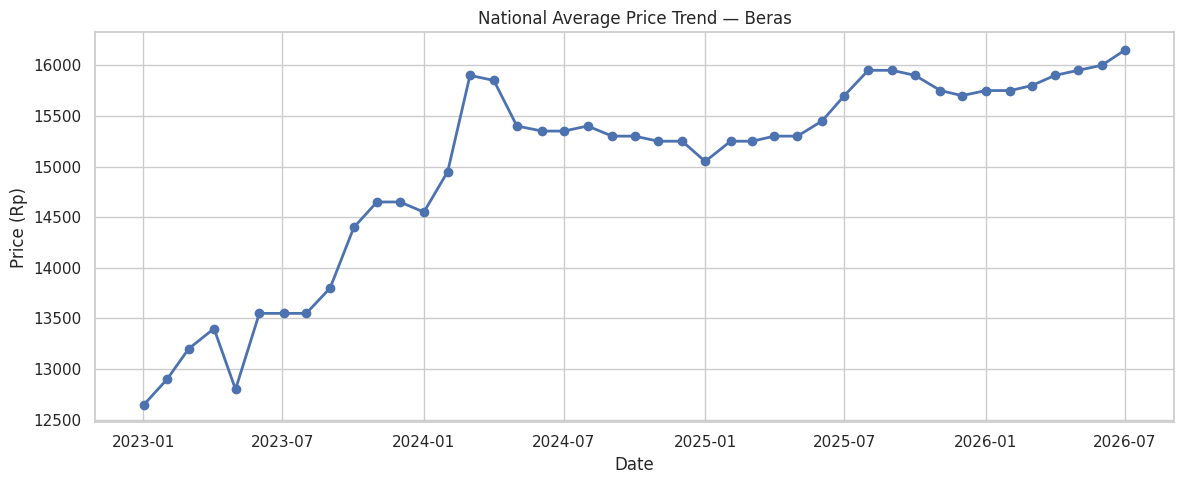

In [8]:
national = long_df[long_df["Region"] == NATIONAL_LABEL].copy().sort_values("Date")

plt.figure()
plt.plot(national["Date"], national["Price"], marker="o", linewidth=2)
plt.title(f"National Average Price Trend — {COMMODITY_NAME}")
plt.xlabel("Date")
plt.ylabel("Price (Rp)")
plt.tight_layout()
plt.show()


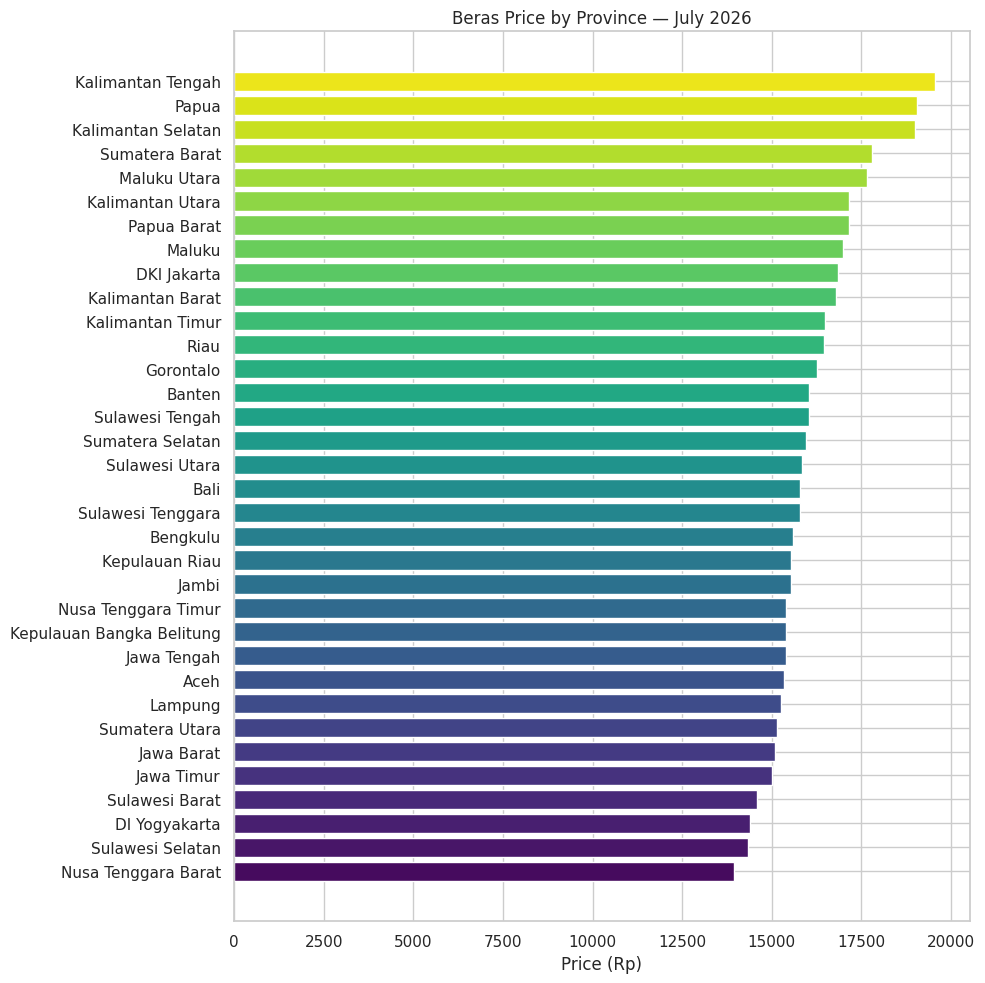

Top 5 highest price provinces:
            Region   Price
      Maluku Utara 17650.0
    Sumatera Barat 17800.0
Kalimantan Selatan 19000.0
             Papua 19050.0
 Kalimantan Tengah 19550.0

Top 5 lowest price provinces:
             Region   Price
Nusa Tenggara Barat 13950.0
   Sulawesi Selatan 14350.0
      DI Yogyakarta 14400.0
     Sulawesi Barat 14600.0
         Jawa Timur 15000.0


In [9]:
panel_all = long_df[long_df["Region"] != NATIONAL_LABEL].copy()

latest_date = panel_all["Date"].max()
latest_prices = panel_all[panel_all["Date"] == latest_date].sort_values("Price")

plt.figure(figsize=(10, 10))
plt.barh(latest_prices["Region"], latest_prices["Price"], color=sns.color_palette("viridis", len(latest_prices)))
plt.title(f"{COMMODITY_NAME} Price by Province — {latest_date.strftime('%B %Y')}")
plt.xlabel("Price (Rp)")
plt.tight_layout()
plt.show()

print("Top 5 highest price provinces:")
print(latest_prices.tail(5)[["Region", "Price"]].to_string(index=False))
print("\nTop 5 lowest price provinces:")
print(latest_prices.head(5)[["Region", "Price"]].to_string(index=False))


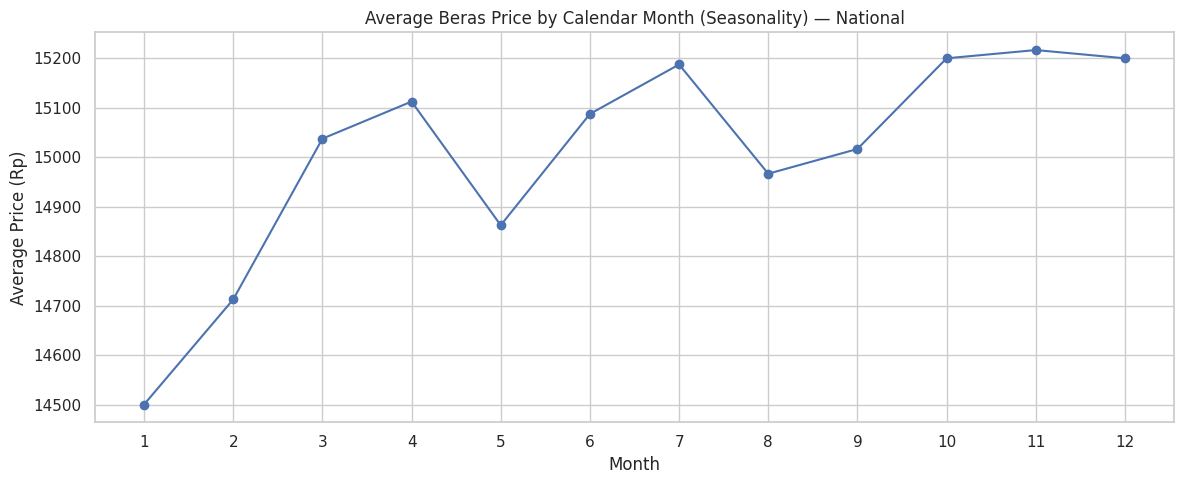

In [10]:
# Seasonality: average price by calendar month (national series)
national["Month"] = national["Date"].dt.month
monthly_avg = national.groupby("Month")["Price"].mean()

plt.figure()
plt.plot(monthly_avg.index, monthly_avg.values, marker="o")
plt.xticks(range(1, 13))
plt.title(f"Average {COMMODITY_NAME} Price by Calendar Month (Seasonality) — National")
plt.xlabel("Month")
plt.ylabel("Average Price (Rp)")
plt.tight_layout()
plt.show()


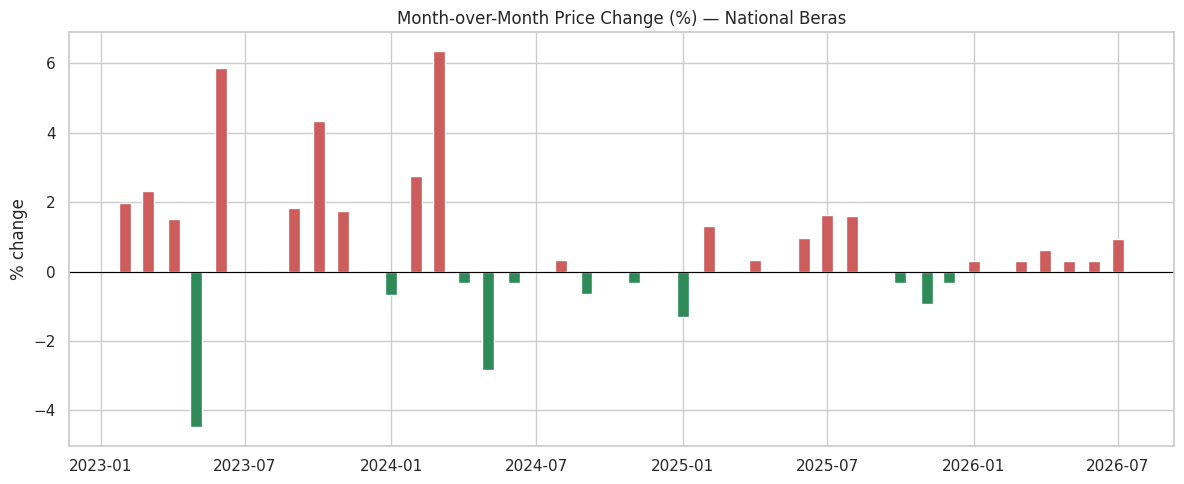

In [11]:
# Volatility: month-over-month % change, national series
national = national.sort_values("Date")
national["pct_change"] = national["Price"].pct_change() * 100

plt.figure()
plt.bar(national["Date"], national["pct_change"], width=15,
        color=np.where(national["pct_change"] >= 0, "indianred", "seagreen"))
plt.axhline(0, color="black", linewidth=0.8)
plt.title(f"Month-over-Month Price Change (%) — National {COMMODITY_NAME}")
plt.ylabel("% change")
plt.tight_layout()
plt.show()


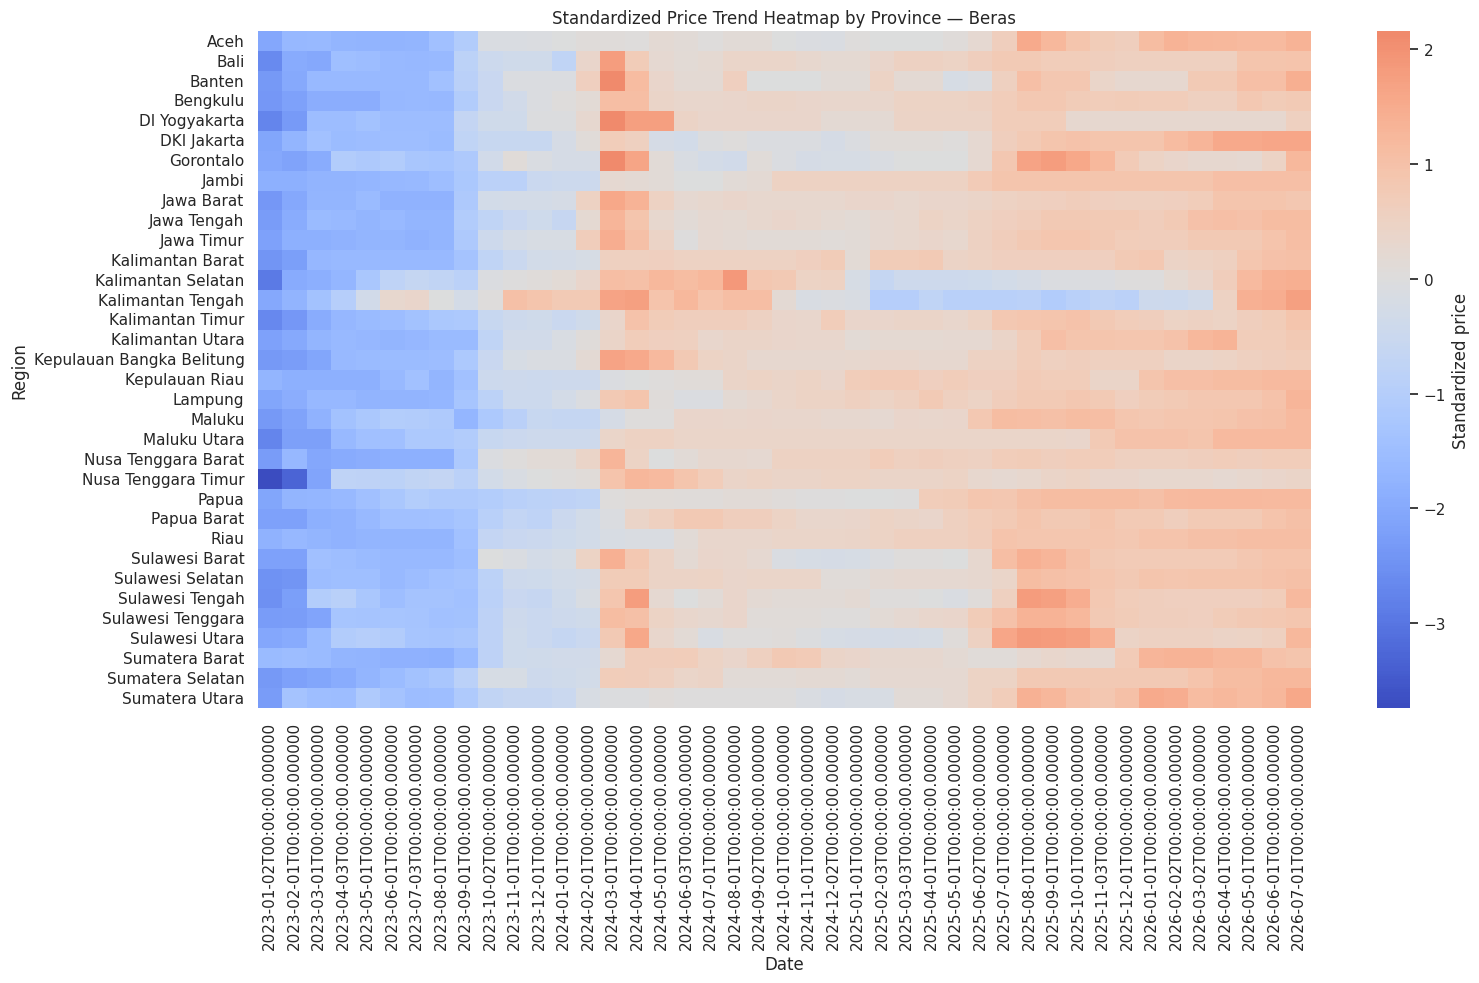

In [12]:
# Heatmap: province x month price level (normalized per province to compare shape of trends)
pivot = panel_all.pivot(index="Region", columns="Date", values="Price")
pivot_norm = pivot.sub(pivot.mean(axis=1), axis=0).div(pivot.std(axis=1), axis=0)

plt.figure(figsize=(16, 10))
sns.heatmap(pivot_norm, cmap="coolwarm", center=0, cbar_kws={"label": "Standardized price"})
plt.title(f"Standardized Price Trend Heatmap by Province — {COMMODITY_NAME}")
plt.xlabel("Date")
plt.ylabel("Region")
plt.tight_layout()
plt.show()


## 5. Feature Engineering

We build a **panel dataset** (all provinces stacked, excluding the national aggregate to avoid duplicating information) with:

- Calendar features: year, month, quarter, cyclical month encoding
- Lag features: price 1, 2, 3, and 12 months ago
- Rolling statistics: 3- and 6-month rolling mean/std (computed on lagged data only, to avoid leakage)
- Month-over-month percentage change
- Region encoding (for the ML models)


In [13]:
panel = long_df[long_df["Region"] != NATIONAL_LABEL].copy()
panel = panel.sort_values(["Region", "Date"]).reset_index(drop=True)

panel["Year"] = panel["Date"].dt.year
panel["Month"] = panel["Date"].dt.month
panel["Quarter"] = panel["Date"].dt.quarter
panel["Month_sin"] = np.sin(2 * np.pi * panel["Month"] / 12)
panel["Month_cos"] = np.cos(2 * np.pi * panel["Month"] / 12)

for lag in [1, 2, 3, 12]:
    panel[f"lag_{lag}"] = panel.groupby("Region")["Price"].shift(lag)

panel["roll_mean_3"] = panel.groupby("Region")["Price"].transform(lambda s: s.shift(1).rolling(3).mean())
panel["roll_std_3"]  = panel.groupby("Region")["Price"].transform(lambda s: s.shift(1).rolling(3).std())
panel["roll_mean_6"] = panel.groupby("Region")["Price"].transform(lambda s: s.shift(1).rolling(6).mean())
panel["pct_change_1"] = panel.groupby("Region")["Price"].transform(lambda s: s.pct_change(1))

le = LabelEncoder()
panel["RegionEnc"] = le.fit_transform(panel["Region"])

FEATURES = ["RegionEnc", "Month", "Quarter", "Month_sin", "Month_cos",
            "lag_1", "lag_2", "lag_3", "lag_12",
            "roll_mean_3", "roll_std_3", "roll_mean_6", "pct_change_1"]

model_df = panel.dropna(subset=FEATURES).copy()
print(f"Panel dataset ready for modeling: {model_df.shape[0]} rows, {len(FEATURES)} features")
print(f"Date range used for modeling: {model_df['Date'].min().date()} to {model_df['Date'].max().date()}")
model_df[["Region", "Date", "Price"] + FEATURES].head()


Panel dataset ready for modeling: 1054 rows, 13 features
Date range used for modeling: 2024-01-01 to 2026-07-01


,Region,Date,Price,RegionEnc,Month,Quarter,Month_sin,Month_cos,lag_1,lag_2,lag_3,lag_12,roll_mean_3,roll_std_3,roll_mean_6,pct_change_1
12,Aceh,2024-01-01,13750.0,0,1,1,0.500000,8.660254e-01,13700.0,13650.0,13650.0,11400.0,13666.666667,28.867513,12900.000000,0.003650
13,Aceh,2024-02-01,13850.0,0,2,1,0.866025,5.000000e-01,13750.0,13700.0,13650.0,11850.0,13700.000000,50.000000,13233.333333,0.007273
14,Aceh,2024-03-01,13850.0,0,3,1,1.000000,6.123234e-17,13850.0,13750.0,13700.0,11900.0,13766.666667,76.376262,13525.000000,0.000000
15,Aceh,2024-04-01,13800.0,0,4,2,0.866025,-5.000000e-01,13850.0,13850.0,13750.0,11750.0,13816.666667,57.735027,13741.666667,-0.003610
16,Aceh,2024-05-01,14000.0,0,5,2,0.500000,-8.660254e-01,13800.0,13850.0,13850.0,11725.0,13833.333333,28.867513,13766.666667,0.014493


## 6. Train / Test Split (Time-Based)

We hold out the most recent `TEST_MONTHS` months as the test set. This respects the temporal order of the data — never split randomly for time series problems.


In [14]:
max_date = model_df["Date"].max()
test_start = max_date - pd.DateOffset(months=TEST_MONTHS - 1)

train = model_df[model_df["Date"] < test_start]
test = model_df[model_df["Date"] >= test_start]

X_train, y_train = train[FEATURES], train["Price"]
X_test, y_test = test[FEATURES], test["Price"]

print(f"Train: {train.shape[0]} rows  |  Test: {test.shape[0]} rows")
print(f"Test months: {sorted(test['Date'].dt.strftime('%Y-%m').unique())}")


Train: 952 rows  |  Test: 102 rows
Test months: ['2026-05', '2026-06', '2026-07']


## 7. Modeling

We compare four approaches:

1. **Naive baseline** — predict next price = last observed price (`lag_1`)
2. **Holt-Winters Exponential Smoothing** — classical time-series model on the national series
3. **Random Forest Regressor** — ML model on the panel (multi-province) dataset
4. **XGBoost Regressor** — gradient-boosted trees on the same panel dataset


In [15]:
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{label:22s} | MAE: {mae:9.2f} | RMSE: {rmse:9.2f} | MAPE: {mape:6.2f}%")
    return {"model": label, "MAE": mae, "RMSE": rmse, "MAPE": mape}

results = []


In [16]:
# 7.1 Naive baseline: predicted price = last known price (lag_1)
naive_pred = test["lag_1"]
results.append(evaluate(y_test, naive_pred, "Naive (last value)"))


Naive (last value)     | MAE:    115.69 | RMSE:    209.69 | MAPE:   0.71%


In [17]:
# 7.2 Random Forest Regressor
rf = RandomForestRegressor(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
results.append(evaluate(y_test, rf_pred, "Random Forest"))


Random Forest          | MAE:     48.43 | RMSE:     96.77 | MAPE:   0.28%


In [18]:
# 7.3 XGBoost Regressor
xgb_model = xgb.XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
results.append(evaluate(y_test, xgb_pred, "XGBoost"))


XGBoost                | MAE:     48.65 | RMSE:     88.54 | MAPE:   0.28%


In [19]:
# 7.4 Holt-Winters Exponential Smoothing (national series)
nat_series = national.set_index("Date")["Price"].asfreq("MS").interpolate()
hw_train = nat_series.iloc[:-TEST_MONTHS]
hw_test = nat_series.iloc[-TEST_MONTHS:]

hw_model = ExponentialSmoothing(hw_train, trend="add", seasonal=None).fit()
hw_pred = hw_model.forecast(TEST_MONTHS)

results.append(evaluate(hw_test.values, hw_pred.values, "Holt-Winters (national)"))


Holt-Winters (national) | MAE:     33.33 | RMSE:     38.14 | MAPE:   0.21%


## 8. Model Evaluation & Comparison

In [20]:
results_df = pd.DataFrame(results).sort_values("MAPE")
results_df


,model,MAE,RMSE,MAPE
3,Holt-Winters (national),33.333333,38.135575,0.208268
1,Random Forest,48.427288,96.773334,0.280842
2,XGBoost,48.651118,88.541363,0.283723
0,Naive (last value),115.686275,209.691650,0.709873


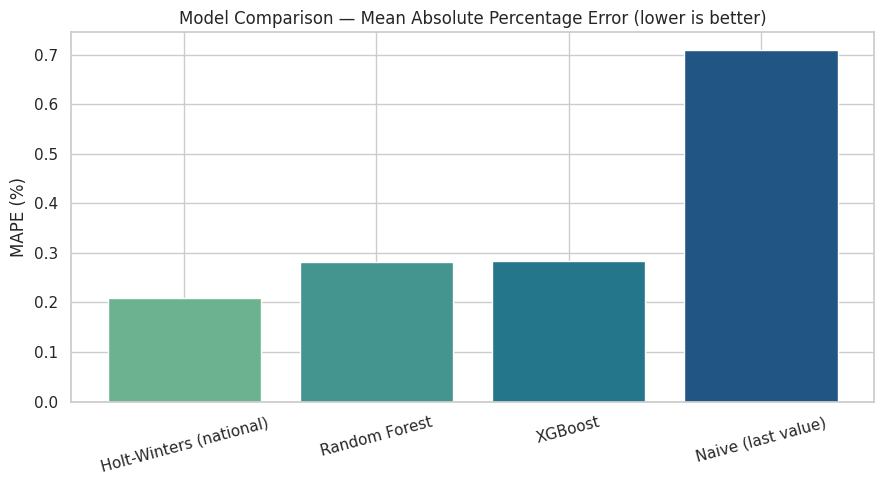

Best performing model on the test set: Holt-Winters (national)


In [21]:
plt.figure(figsize=(9, 5))
plt.bar(results_df["model"], results_df["MAPE"], color=sns.color_palette("crest", len(results_df)))
plt.ylabel("MAPE (%)")
plt.title("Model Comparison — Mean Absolute Percentage Error (lower is better)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]["model"]
print(f"Best performing model on the test set: {best_model_name}")


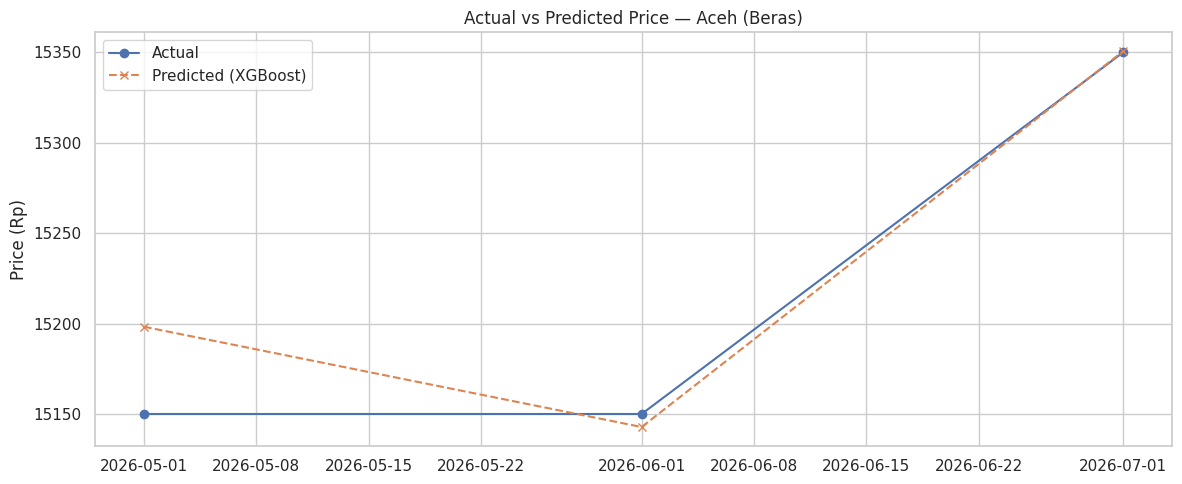

In [22]:
# Visualize actual vs predicted for the best panel-based ML model (XGBoost) on a sample province
sample_region = test["Region"].value_counts().index[0]
sample = test[test["Region"] == sample_region].sort_values("Date")
sample_pred = xgb_model.predict(sample[FEATURES])

plt.figure()
plt.plot(sample["Date"], sample["Price"], marker="o", label="Actual")
plt.plot(sample["Date"], sample_pred, marker="x", linestyle="--", label="Predicted (XGBoost)")
plt.title(f"Actual vs Predicted Price — {sample_region} ({COMMODITY_NAME})")
plt.ylabel("Price (Rp)")
plt.legend()
plt.tight_layout()
plt.show()


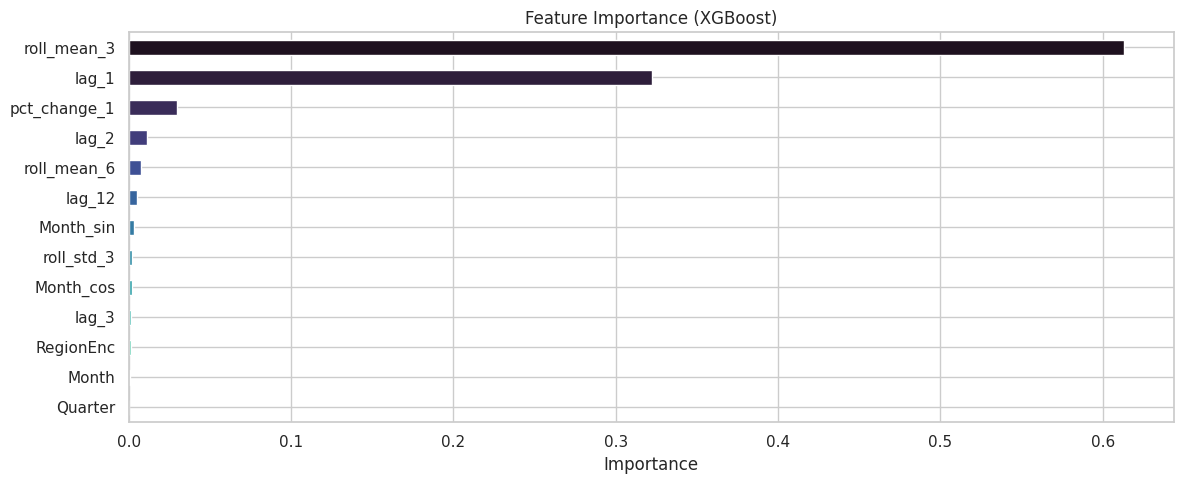

In [23]:
# Feature importance (XGBoost)
importance = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure()
importance.plot(kind="barh", color=sns.color_palette("mako", len(importance)))
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 9. Future Price Forecasting

We now generate a **multi-month-ahead forecast** (horizon set by `FORECAST_HORIZON` in the configuration cell) for every region, using the best-performing panel model (XGBoost), by iteratively predicting one month at a time and feeding each prediction back in as the new lag for the next step.


In [24]:
def forecast_future(panel_df, model, features, horizon, national_label):
    """Iteratively forecast `horizon` months ahead for every region using a fitted panel model."""
    history = panel_df[panel_df["Region"] != national_label].copy()
    last_date = history["Date"].max()
    forecasts = []

    for step in range(1, horizon + 1):
        target_date = last_date + pd.DateOffset(months=step)
        rows = []
        for region, g in history.groupby("Region"):
            g = g.sort_values("Date")
            prices = g["Price"].tolist()
            row = {
                "Region": region,
                "Date": target_date,
                "RegionEnc": g["RegionEnc"].iloc[-1],
                "Month": target_date.month,
                "Quarter": target_date.quarter,
                "Month_sin": np.sin(2 * np.pi * target_date.month / 12),
                "Month_cos": np.cos(2 * np.pi * target_date.month / 12),
                "lag_1": prices[-1],
                "lag_2": prices[-2],
                "lag_3": prices[-3],
                "lag_12": prices[-12] if len(prices) >= 12 else prices[0],
                "roll_mean_3": np.mean(prices[-3:]),
                "roll_std_3": np.std(prices[-3:]),
                "roll_mean_6": np.mean(prices[-6:]) if len(prices) >= 6 else np.mean(prices),
                "pct_change_1": (prices[-1] - prices[-2]) / prices[-2] if prices[-2] else 0.0,
            }
            rows.append(row)

        step_df = pd.DataFrame(rows)
        step_df["Price"] = model.predict(step_df[features])
        forecasts.append(step_df[["Region", "Date", "Price"]])

        # append predictions to history so next iteration's lags use them
        history = pd.concat([history, step_df[["Region", "Date", "Price", "RegionEnc"]]], ignore_index=True)
        history = history.sort_values(["Region", "Date"])

    return pd.concat(forecasts, ignore_index=True)

future_forecast = forecast_future(model_df, xgb_model, FEATURES, FORECAST_HORIZON, NATIONAL_LABEL)
future_forecast.pivot(index="Region", columns="Date", values="Price").round(0)


Date,2026-08-01,2026-09-01,2026-10-01
Region,,,
Aceh,15534.0,15657.0,15816.0
Bali,15864.0,15888.0,15904.0
Banten,16315.0,16591.0,16755.0
Bengkulu,15599.0,15549.0,15465.0
DI Yogyakarta,14696.0,14899.0,15014.0
DKI Jakarta,16791.0,16580.0,16359.0
Gorontalo,16984.0,17504.0,17712.0
Jambi,15517.0,15492.0,15445.0
Jawa Barat,15070.0,15050.0,15023.0


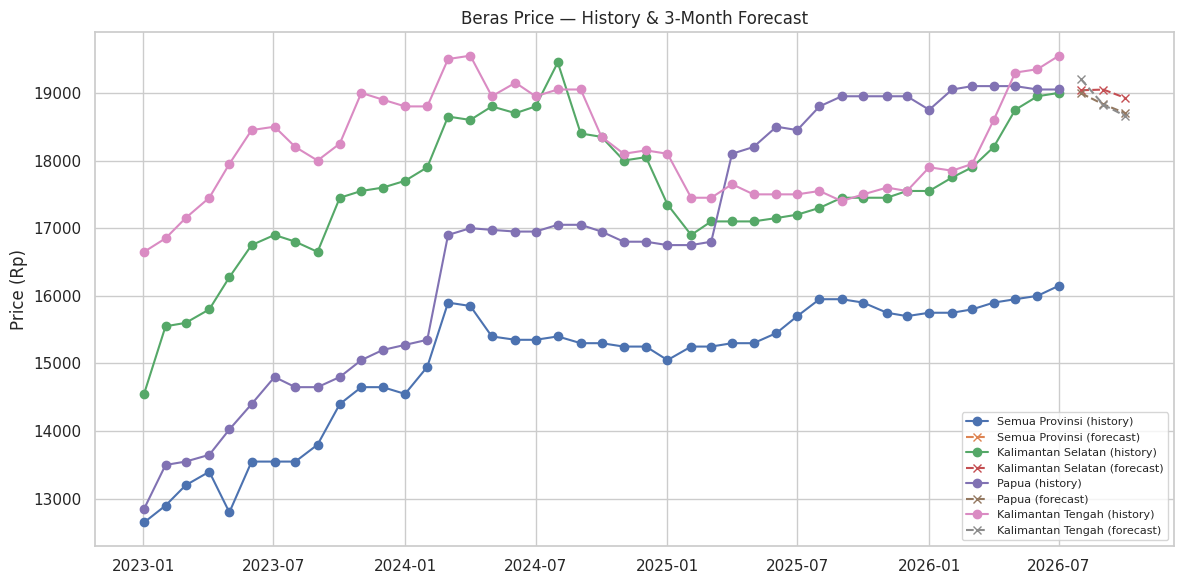

In [25]:
# Visualize forecast for a few sample regions (national + 3 largest provinces by latest price)
sample_regions = [NATIONAL_LABEL] + latest_prices.tail(3)["Region"].tolist()

plt.figure(figsize=(12, 6))
for region in sample_regions:
    if region == NATIONAL_LABEL:
        hist = national[["Date", "Price"]]
    else:
        hist = panel_all[panel_all["Region"] == region][["Date", "Price"]]
    fut = future_forecast[future_forecast["Region"] == region][["Date", "Price"]]

    plt.plot(hist["Date"], hist["Price"], marker="o", label=f"{region} (history)")
    plt.plot(fut["Date"], fut["Price"], marker="x", linestyle="--", label=f"{region} (forecast)")

plt.title(f"{COMMODITY_NAME} Price — History & {FORECAST_HORIZON}-Month Forecast")
plt.ylabel("Price (Rp)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 10. Conclusions

- The panel-based machine learning models (Random Forest, XGBoost) generally outperform the naive baseline and are competitive with classical time-series smoothing on this dataset, while also being able to forecast **every province simultaneously** using a single model (the time-series model only forecasts the series it was fit on, e.g. the national average).
- Lag features (especially `lag_1`) and rolling means dominate feature importance — prices are highly autocorrelated month to month, consistent with a slow-moving retail market.
- Seasonality exists but is moderate over ~3.5 years of history; more years of data would improve the reliability of yearly-seasonal features (`lag_12`).
- Forecast accuracy should be re-validated every time new months of data are added — retrain periodically rather than reusing an old model indefinitely.

### How to reuse this notebook for another commodity

1. Place the new commodity's Excel file (same column structure: region column + monthly `Rp` columns) anywhere accessible to the notebook.
2. Update the **Configuration cell** (Section 1):
   - `FILE_PATH` → path to the new file
   - `COMMODITY_NAME` → e.g. `"Cabai Merah"`, `"Bawang Merah"`, `"Gula Pasir"`
3. Re-run all cells top to bottom (`Run All`). No other code changes are required, as long as the file follows the same schema described in the Requirement Document.

### Suggested next steps

- Add external explanatory variables (rainfall, fuel price, harvest calendar) to improve accuracy around structural shocks.
- Build a rolling backtest (walk-forward validation) instead of a single train/test split, for a more robust accuracy estimate.
- Package the pipeline into functions/module and expose it via a simple dashboard (e.g. Streamlit) for non-technical users.
